In [25]:
from google.colab import drive
from google.colab import drive
import pandas as pd
import json
import os

In [26]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Define paths
file_path = '/content/drive/MyDrive/shaped-coffee-bean-products.json'
with open(file_path, 'r') as f:
    data = json.load(f)

In [39]:
# Extract list of products
products = [item['product'] for item in data]

In [52]:
# Check column names first
print(df.columns)

Index(['beanId', 'name', 'image', 'webpage', 'gram', 'roastDegree',
       'availability', 'price', 'pricePerCup', 'bulkPricePerCup', 'flavors',
       'producers', 'roaster_name', 'roaster_country', 'process_name',
       'process_tag', 'process', 'flavor_tags', 'producer_names',
       'combined_features'],
      dtype='object')


In [40]:
# Flatten the nested structure (including roaster and process)
df = pd.json_normalize(
    products,
    sep='_',
    meta=[
        ['roaster', 'name'],
        ['roaster', 'country'],
        ['process', 'name'],
        ['process', 'tag']
    ],
    errors='ignore'
)

In [37]:
# Rename extracted nested fields
df.rename(columns={
    'roaster_name': 'roaster_name',
    'roaster_country': 'roaster_country',
    'process_name': 'process_name',
    'process_tag': 'process_tag'
}, inplace=True)

In [41]:
# Fill NaNs
df['roaster_name'] = df['roaster_name'].fillna('unknown')
df['roaster_country'] = df['roaster_country'].fillna('unknown')
df['process_name'] = df['process_name'].fillna('unknown')
df['process_tag'] = df['process_tag'].fillna('unknown')

In [42]:
# Success check
print(df[['name', 'roaster_name', 'roaster_country', 'process_name']].head())

                                       name        roaster_name  \
0          el salvador - pirineos (natural)  three marks coffee   
1  el salvador- los pirineos- elite bourbon  three marks coffee   
2            colombia - wilder lazo (gesha)  three marks coffee   
3            colombia - wilder lazo (sidra)  three marks coffee   
4              colombia - el placer (gesha)  three marks coffee   

  roaster_country              process_name  
0           spain                   natural  
1           spain               black honey  
2           spain                   natural  
3           spain                    washed  
4           spain  white honey, semi-washed  


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Convert list-like columns to strings
df['flavor_tags'] = df['flavors'].apply(lambda x: ', '.join([i['name'] for i in x]) if isinstance(x, list) else 'unknown')
df['producer_names'] = df['producers'].apply(lambda x: ', '.join([i['name'] for i in x]) if isinstance(x, list) else 'unknown')

# Combine features for similarity
df['combined_features'] = (
    df['name'].astype(str) + ' ' +
    df['roastDegree'].astype(str) + ' ' +
    df['process_name'].astype(str) + ' ' +
    df['process_tag'].astype(str) + ' ' +
    df['flavor_tags'] + ' ' +
    df['producer_names'] + ' ' +
    df['roaster_name'] + ' ' +
    df['roaster_country']
)

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['combined_features'])

# Compute cosine similarity
similarity_matrix = cosine_similarity(tfidf_matrix)


In [55]:
from IPython.display import display, HTML

def recommend_coffee(name, top_n=5, roast=None, country=None, max_price=None, export=False):
    name = name.lower()
    idx = df[df['name'].str.lower() == name]
    if idx.empty:
        return f"❌ Coffee '{name}' not found in dataset."

    idx = idx.index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = [x for x in sim_scores if x[0] != idx]  # Exclude self
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply filters
    filtered_df = df.copy()
    if roast:
        filtered_df = filtered_df[filtered_df['roastDegree'].str.lower() == roast.lower()]
    if country:
        filtered_df = filtered_df[filtered_df['roaster_country'].str.lower() == country.lower()]
    if max_price:
        filtered_df = filtered_df[pd.to_numeric(filtered_df['price'], errors='coerce') <= max_price]

    # Merge similarity
    sim_df = pd.DataFrame(sim_scores, columns=['index', 'similarity'])
    filtered_df = filtered_df.merge(sim_df, left_index=True, right_on='index')

    results = filtered_df.sort_values(by='similarity', ascending=False).head(top_n)

    if export:
        results.to_csv('/content/recommended_coffees.csv', index=False)
        results.to_json('/content/recommended_coffees.json', orient='records')
        print("✅ Exported to /content/")

    # Display with image in Colab
    for _, row in results.iterrows():
        display(HTML(f"""
            <h4>{row['name']}</h4>
            <img src="{row['image']}" width="200"><br>
            <b>Roast:</b> {row['roastDegree']} |
            <b>Country:</b> {row['roaster_country']} |
            <b>Price:</b> ${row['price']}<br>
            <b>Flavors:</b> {row['flavor_tags']}<br>
            <hr>
        """))

    return results[['name', 'roastDegree', 'roaster_country', 'price', 'flavor_tags', 'similarity']]


In [56]:
recommend_coffee(
    name="el salvador - pirineos (natural)",
    top_n=5,
    roast="omni",
    country="spain",
    max_price=20,
    export=True
)


✅ Exported to /content/


,name,roastDegree,roaster_country,price,flavor_tags,similarity
40,guatemala - casco,omni,spain,18.76,"grape, blue berry, berry",0.323617
44,guatemala - la pila,omni,spain,16.68,"sweet, red apple, vanilla",0.285653
46,ethiopia - uraga raro,omni,spain,17.72,"candy, caramel, sweet",0.273279
48,ethiopia - daye bensa,omni,spain,13.55,"tropical fruit, lemon, bergamot, citrus, blood...",0.266652
51,kenya - thunguri nyeri ab,omni,spain,16.68,"blue berry, berry, grape fruit, honey, citrus,...",0.238926


In [10]:
# Count NaN values in each column
nan_counts = df.isna().sum()

# Print the count of NaN values
print(nan_counts)

beanId                 0
name                   0
image               7080
webpage                0
gram                   0
roastDegree         2049
availability           0
price                  0
pricePerCup            0
bulkPricePerCup        0
flavors                0
producers              0
roaster_name           0
roaster_country        0
process_name         467
process_tag          500
process            10285
dtype: int64


In [57]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00


In [58]:
import ipywidgets as widgets
from IPython.display import display

# Widgets
coffee_selector = widgets.Dropdown(options=df['name'].unique(), description='Coffee:')
roast_selector = widgets.Dropdown(options=[''] + sorted(df['roastDegree'].dropna().unique()), description='Roast:')
country_selector = widgets.Dropdown(options=[''] + sorted(df['roaster_country'].dropna().unique()), description='Country:')
price_slider = widgets.FloatSlider(value=25, min=5, max=50, step=0.5, description='Max Price:')
top_n_slider = widgets.IntSlider(value=5, min=1, max=10, description='Top N:')

# Display all inputs
display(coffee_selector, roast_selector, country_selector, price_slider, top_n_slider)


Dropdown(description='Coffee:', options=('el salvador - pirineos (natural)', 'el salvador- los pirineos- elite…

Dropdown(description='Roast:', options=('', 'dark', 'espresso', 'filter', 'filter light', 'light', 'light espr…

Dropdown(description='Country:', options=('', 'australia', 'austria', 'belgium', 'canada', 'china', 'czech rep…

FloatSlider(value=25.0, description='Max Price:', max=50.0, min=5.0, step=0.5)

IntSlider(value=5, description='Top N:', max=10, min=1)

In [65]:
recommend_coffee(
    name=coffee_selector.value,
    roast=roast_selector.value if roast_selector.value else None,
    country=country_selector.value if country_selector.value else None,
    max_price=price_slider.value,
    top_n=top_n_slider.value
)

,name,roastDegree,roaster_country,price,flavor_tags,similarity


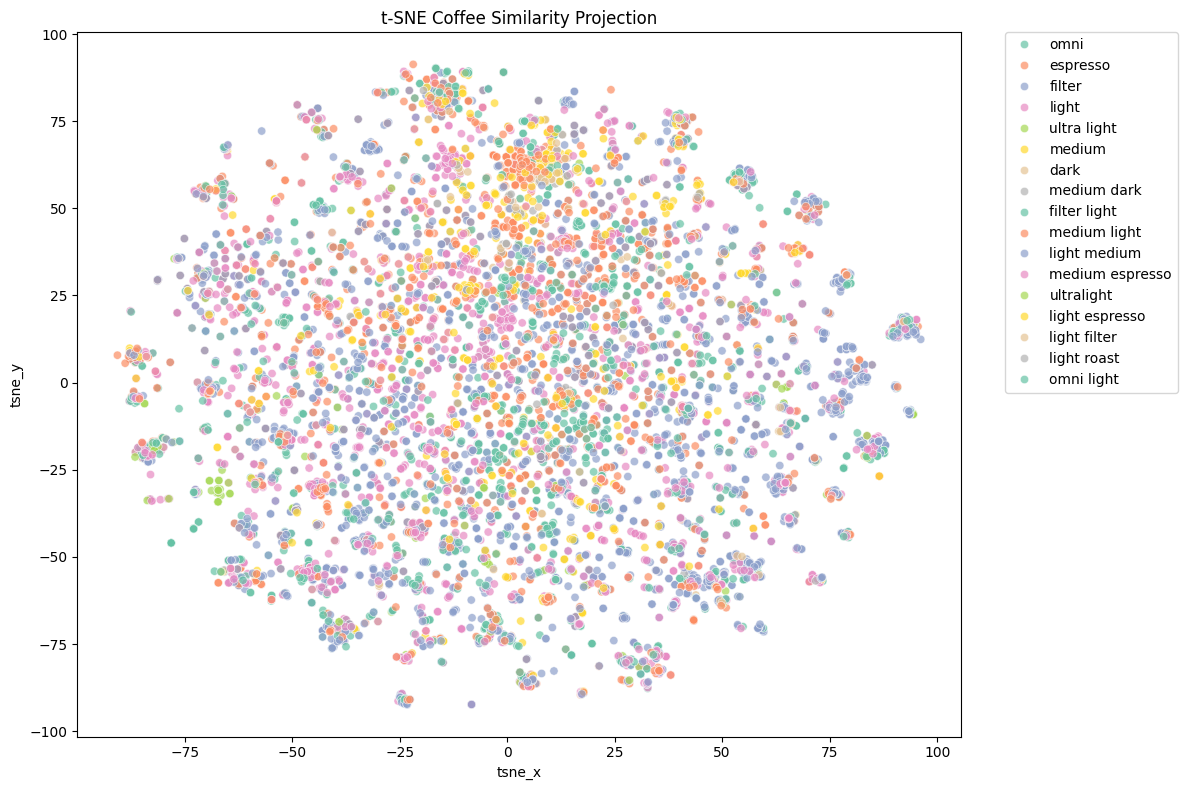

In [60]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Run t-SNE (takes ~10-20s)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(tfidf_matrix.toarray())

df['tsne_x'] = tsne_result[:, 0]
df['tsne_y'] = tsne_result[:, 1]

# Plot t-SNE with roast coloring
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_x', y='tsne_y',
    hue='roastDegree',
    palette='Set2',
    data=df,
    alpha=0.7
)
plt.title('t-SNE Coffee Similarity Projection')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()